# CustomerIQ - Day 8: Customer Risk Scoring

This notebook converts the validated Gradient Boosting model from Day 7 into an actionable customer-level risk layer.

## Why this matters for CustomerIQ
The transition from raw machine learning predictions to structured risk scoring represents a critical step in turning predictive intelligence into business value:

**ML -> Risk Score -> Customer Segment -> Business Action -> Power BI -> AI Recommendation**

By categorizing customers into action-oriented risk segments (HIGH, MEDIUM, LOW), the retention team can prioritize high-value targets, allocate intervention resources efficiently, and track the overall health of the customer base on the executive dashboard.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
FEATURES = [
    'Frequency',
    'Monetary',
    'Recency',
    'Customer Lifespan',
    'Average Purchase Interval',
    'Median Purchase Interval',
]
TARGET = 'observed_churn'
ID_COLUMN = 'Customer ID'

input_path = Path('../Data/Processed/customer_churn_analysis.csv')
output_path = Path('../Data/Processed/customer_risk_scores.csv')
plot_path = Path('../Docs/12_risk_segment_distribution.png')

print('✓ Libraries loaded successfully')

✓ Libraries loaded successfully


In [2]:
# 1. Load data
customers = pd.read_csv(input_path)
print(f'Dataset shape: {customers.shape}')
assert customers.shape[0] == 3705, f'Expected 3705 rows, got {customers.shape[0]}'
print('✓ Dataset loaded successfully')

Dataset shape: (3705, 11)
✓ Dataset loaded successfully


In [3]:
# 2. Recreate feature preparation and split
X = customers[FEATURES].copy()
y = customers[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)
print(f'Training size: {X_train.shape[0]}')
print(f'Test size: {X_test.shape[0]}')

Training size: 2964
Test size: 741


In [4]:
# 3. Train Gradient Boosting model (matching Day 7 config)
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE,
)
gb_model.fit(X_train, y_train)
print('✓ Gradient Boosting model trained successfully')

✓ Gradient Boosting model trained successfully


In [5]:
# 4. Generate probabilities and risk segments
# Generate probabilities for ALL eligible customers
customers['churn_probability'] = gb_model.predict_proba(X)[:, 1]

# Assign risk segments based on business prototype thresholds
def assign_risk_segment(prob):
    if prob >= 0.70:
        return 'HIGH'
    elif prob >= 0.40:
        return 'MEDIUM'
    else:
        return 'LOW'

customers['risk_segment'] = customers['churn_probability'].apply(assign_risk_segment)
print('✓ Probabilities and risk segments assigned')

✓ Probabilities and risk segments assigned


In [6]:
# 5. Export results
output_cols = [
    ID_COLUMN,
    'churn_probability',
    'risk_segment',
    'Frequency',
    'Monetary',
    'Recency',
    'Customer Lifespan',
    'Average Purchase Interval',
    'Median Purchase Interval',
]
risk_scores = customers[output_cols].copy()
risk_scores.to_csv(output_path, index=False)
print(f'✓ Risk scores exported to {output_path}')

✓ Risk scores exported to ..\Data\Processed\customer_risk_scores.csv


In [7]:
# 6. Validate constraints
print('='*50)
print('DATA VALIDATION RUN')
print('='*50)

# Row count check
print(f'Customer count: {len(risk_scores)}')
assert len(risk_scores) == 3705, f'Expected 3705 rows, found {len(risk_scores)}'

# Duplicate ID check
print(f'Duplicate IDs: {risk_scores[ID_COLUMN].duplicated().sum()}')
assert risk_scores[ID_COLUMN].is_unique, 'Duplicate Customer IDs detected!'

# Missing values check
print(f'Missing probabilities: {risk_scores["churn_probability"].isna().sum()}')
assert risk_scores['churn_probability'].notna().all(), 'Missing probabilities found!'

# Probability bounds check
print(f'Probabilities out of bounds: {((risk_scores["churn_probability"] < 0) | (risk_scores["churn_probability"] > 1)).sum()}')
assert risk_scores['churn_probability'].between(0, 1).all(), 'Probabilities out of bounds [0, 1]!'

# Segment valid check
invalid_segments = risk_scores[~risk_scores['risk_segment'].isin(['HIGH', 'MEDIUM', 'LOW'])]
print(f'Invalid risk segments: {len(invalid_segments)}')
assert len(invalid_segments) == 0, 'Invalid risk segments detected!'

print('✓ All validation checks passed successfully!')

DATA VALIDATION RUN
Customer count: 3705
Duplicate IDs: 0
Missing probabilities: 0
Probabilities out of bounds: 0
Invalid risk segments: 0
✓ All validation checks passed successfully!


In [8]:
# 7. Print summary statistics
total_customers = len(risk_scores)
counts = risk_scores['risk_segment'].value_counts()
pcts = risk_scores['risk_segment'].value_counts(normalize=True) * 100

print('='*50)
print('CUSTOMER RISK SUMMARY STATISTICS')
print('='*50)
print(f'Total Scored Customers: {total_customers}')
for segment in ['HIGH', 'MEDIUM', 'LOW']:
    count = counts.get(segment, 0)
    pct = pcts.get(segment, 0.0)
    print(f'{segment:<8} Risk: {count:>5d} ({pct:.2f}%)')

mean_prob = risk_scores['churn_probability'].mean()
print(f'\nMean Churn Probability: {mean_prob:.6f}')

CUSTOMER RISK SUMMARY STATISTICS
Total Scored Customers: 3705
HIGH     Risk:   690 (18.62%)
MEDIUM   Risk:  1511 (40.78%)
LOW      Risk:  1504 (40.59%)

Mean Churn Probability: 0.465952


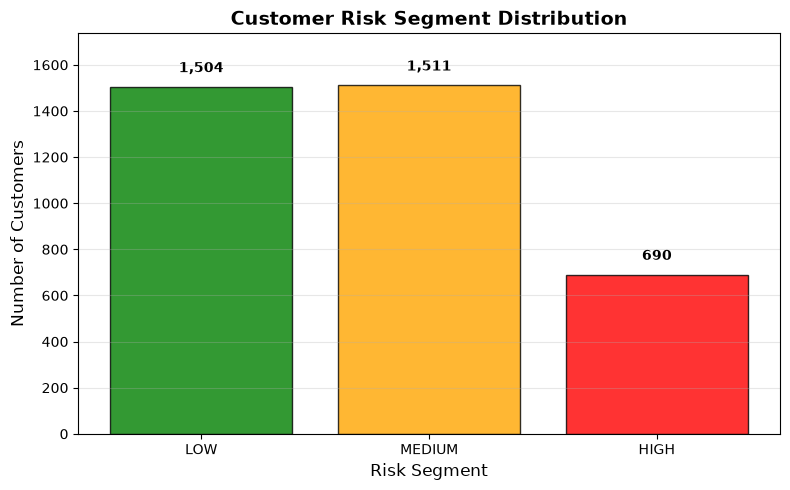

✓ Visualisation saved to ..\Docs\12_risk_segment_distribution.png


In [9]:
# 8. Simple visualization of risk segment distribution
segment_counts = risk_scores['risk_segment'].value_counts().reindex(['LOW', 'MEDIUM', 'HIGH'])
colors = ['green', 'orange', 'red']

plt.figure(figsize=(8, 5))
bars = plt.bar(segment_counts.index, segment_counts.values, color=colors, edgecolor='black', alpha=0.8)

# Add labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, f'{yval:,}', ha='center', va='bottom', fontweight='bold')

plt.title('Customer Risk Segment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Risk Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.ylim(0, segment_counts.max() * 1.15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(plot_path, dpi=300)
plt.show()
print(f'✓ Visualisation saved to {plot_path}')